
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

  



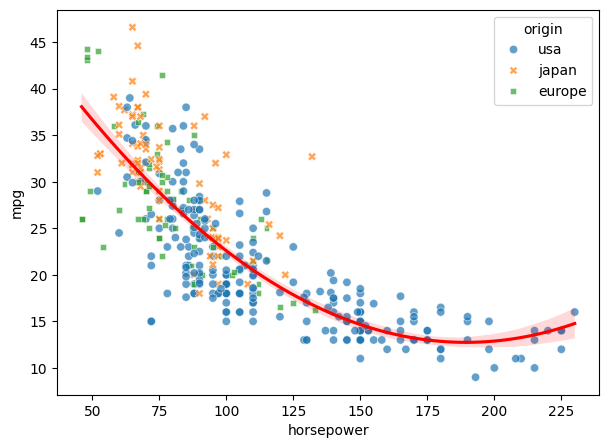

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargo el dataset
df_mpg = pd.read_csv("millas_por_galon.csv")

# limpio los datos para evitr espacios vacios o con errores
df_mpg['horsepower'] = pd.to_numeric(df_mpg['horsepower'], errors='coerce')

# saco los datos que voy a comparar
df_mpg = df_mpg.dropna(subset=['mpg', 'horsepower', 'origin'])

# Creo la figura y los ejes con el tamaño querido
fig, ax = plt.subplots(figsize=(7, 5))

#uso scatterplot para personalizar los puntos y regplot para el análisis estadistico

# Grafico los puntos diferenciados por color y forma de acuerdo al pais
sns.scatterplot(
    data=df_mpg,
    x='horsepower',
    y='mpg',
    hue='origin',       # Diferencio cada pais con un color
    style='origin',     # Diferencia cada pais con una figura
    ax=ax,
    alpha=0.7
)

# Genero la gráfica de regresion usando regplot que me permite hacer la grafica de dos variables, comparandolas con el 95 ci
sns.regplot(
    data=df_mpg,
    x='horsepower',       # Eje X: Potencia en caballos de fuerza
    y='mpg',              # Eje Y: Millas por galón
    ax=ax,                # Le digo que se dibuje en los ejes que creo arriba en fig, ax
    order = 2,            # Realizo un ajuste en orden dos, para que la curva se adecue a los datos
    ci=95,                # Nivel de confianza al 95% (la banda sombreada roja)
    scatter=False,        # Apago los puntos de regplot para no duplicarlos sobre el scatterplot
    line_kws={'color': 'red'}  # Color de la línea de ajuste
)

plt.show()

**conclusiones por Región:**

**Japón**: Muestra los valores mas eficientes en economía de combustible, alcanzando maximos por encima de 40 mpg. Su distribución ess principalmente a motores de menor potencia (menor a 125-130 hp), manteniendo un rendimiento mayor al de la competencia en otros paises que prefieren hp o equilibrio.

**EE. UU**: Representa el volumen principal del dataset y se caracterizanpor tener la mayor potencia (>150 hp). Presenta un comportamiento con clara tendencia a la pérdida de rendimiento a medida que suben los caballos de fuerza, aunque en un momento se ve como el rendimiento deja de caer (más de 175 hp), el consumo deja de caer exponencialmente y se estabiliza cerca del límite inferior (entre 8 y 15 mpg).


**Europa**: Exhibe una distribución equilibrada pero con bastante dispersión en eficiencias para rangos de potencia bajos (40-80 hp). Parece que buscan equilibrio con el fin de ser accesibles y faciles de regular a niveles generales.

**Conclusiones Generales del Modelo:**

Tendencia no lineal (Ajuste cuadrático): La relación entre potencia y millas por galón es claramente negativa pero no decrece de forma lineal. En los primeros incrementos de potencia (de 50 a 125 hp) el impacto en la pérdida de eficiencia es muy notorio, pero a partir de los 150 hp el costo en consumo por caballo se reduce significativamente.


Variabilidad inter-regional: La sobreposición de datos en la zona entre 50 a 100 hp muestra que a igualdad de caballos de fuerza existen diferencias en el rendimiento según el origen del vehiculo. Osea que hay muchos factores a tener en cuenta en la relacion de mpg de un vehiculo, y no solo sus caballos de fuerza, como la construccion y materiales del vehiculo que cambian su peso y forma.




ECUACION DE LA CURVA DE AJUSTE????

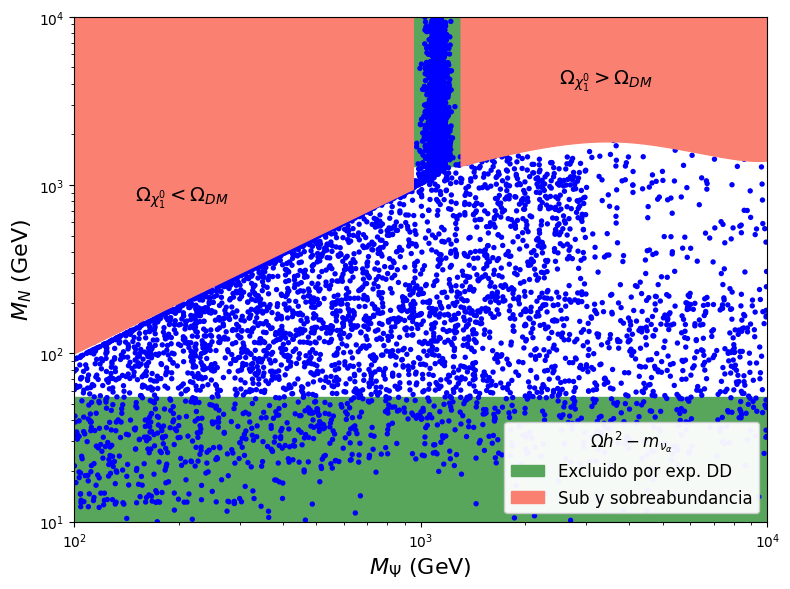

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# 1. Cargo los datos
df = pd.read_csv('general-scan.csv')

# 2. Calculo M_N con la fórmula: M_N = h_s * v_s / sqrt(2)
df['MN'] = (df['YRC'] * df['vS']) / np.sqrt(2)

# 3. Preparo el espacio para dibujar la gráfica
plt.figure(figsize=(8, 6))

# 4. Armo los colores de fondo
# Rango del eje X para poder pintar bien las zonas de color (sin esto no se ven las partes salmón)
x_log = np.logspace(2, 4, 1000)

# Unos valores que definí a ojo para cuadrar las regiones y que queden igual a la imagen de referencia
inicio_columna_x = 950     # Borde izquierdo de la barra verde
fin_columna_x = 1300       # Borde derecho de la barra verde
base_columna_y = 1300      # La base donde se corta la barra verde

# Zona verde de abajo
plt.fill_between([100, 10000], 10, 55, color='#58A55C', alpha=1, label='Excluido por exp. DD', zorder=0)

# La parte verde vertical de arriba
# limito la parte de abajo a base_columna_y
plt.fill_between([inicio_columna_x, fin_columna_x], base_columna_y, 10000, color='#58A55C', alpha=1, zorder=0)

# Zona salmón de arriba a la izquierda
# Le meto un 'where' para limitar la X, y uso x_relleno para trazar la línea diagonal
plt.fill_between(x_log, x_log, 10000,
                 where=(x_log <= inicio_columna_x),
                 zorder = 2,
                 color='#FA8072', alpha=1, label='Sub y sobreabundancia')

# Zona salmón de arriba a la derecha
# Uso una interpolación para suavizar el borde guiándome por la figura original
# arreglo los puntos para empezar justo en la esquina de la columna verde
x_curva = [fin_columna_x, 2000, 3000, 5000, 7000, 10000]
y_curva = [base_columna_y, 1600, 1800, 1700, 1500, 1400]
f_interpolada = interp1d(x_curva, y_curva, kind='cubic', fill_value="extrapolate")

# Relleno de color desde esa curva interpolada hasta 10000, empezando en fin_columna_x
plt.fill_between(x_log, f_interpolada(x_log), 10000,
                 where=(x_log >= fin_columna_x),
                 zorder=2,
                 color='#FA8072', alpha=1)

# 5. Pongo los puntos del escaneo general
sns.scatterplot(
    data=df,
    x='MDF',       # M_Psi
    y='MN',        # M_N
    color='blue',
    s=15,          # Tamaño de los puntos
    edgecolor='none',
    zorder=1       # Esto asegura que los puntos queden por encima del fondo
)
# 6. Pongo los ejes en escala logarítmica y limito hasta dónde se ven
plt.xscale('log')
plt.yscale('log')
plt.xlim(100, 10000)
plt.ylim(10, 10000)

# 7. Le pongo los nombres a los ejes (uso formato LaTeX para que se vean bien las letras matemáticas)
plt.xlabel(r'$M_\Psi$ (GeV)', fontsize=16)
plt.ylabel(r'$M_N$ (GeV)', fontsize=16)

# 8. Pongo los textos sueltos que van flotando dentro de las zonas salmón
plt.text(150, 800, r'$\Omega_{\chi_1^0} < \Omega_{DM}$', fontsize=14, weight='bold')
plt.text(2500, 4000, r'$\Omega_{\chi_1^0} > \Omega_{DM}$', fontsize=14, weight='bold')

# 9. ajusto la forma y posicion de los omega en pantalla para que parezcan los d la imagen original
plt.legend(
    title=r'$\Omega h^2 - m_{\nu_\alpha}$',
    loc='lower right',
    framealpha=0.95,
    fontsize=12,
    title_fontsize=12
)

# Ajusto un poco los márgenes para que nada quede cortado y muestro la gráfica
plt.tight_layout()
plt.show()

NOTA 4.8 